# Brain Stroke Risk Prediction using Machine Learning

This notebook demonstrates a complete machine learning pipeline for predicting stroke risk using medical demographic data. It includes data preprocessing, exploratory analysis, model training, evaluation, and deployment considerations for a Flask web application.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
import joblib
import pickle
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## 2. Load and Explore Medical Demographic Data

You can either load data from a CSV file or create sample data. This cell will generate and save a sample medical demographic dataset as CSV, which you can then use or replace with your own data.

In [2]:
# Option 1: Create and save sample medical demographic dataset as CSV
import os

# Create sample data
np.random.seed(42)
n_samples = 2000

data = {
    'id': range(1, n_samples + 1),
    'age': np.random.randint(20, 85, n_samples),
    'gender': np.random.choice(['Male', 'Female'], n_samples),
    'hypertension': np.random.choice([0, 1], n_samples, p=[0.9, 0.1]),
    'heart_disease': np.random.choice([0, 1], n_samples, p=[0.95, 0.05]),
    'ever_married': np.random.choice(['Yes', 'No'], n_samples),
    'work_type': np.random.choice(['Private', 'Self-employed', 'Govt_job', 'Never_worked'], n_samples),
    'residence_type': np.random.choice(['Urban', 'Rural'], n_samples),
    'avg_glucose_level': np.random.uniform(60, 300, n_samples),
    'bmi': np.random.uniform(10, 50, n_samples),
    'smoking_status': np.random.choice(['never', 'formerly', 'smokes', 'Unknown'], n_samples),
    'stroke': np.random.choice([0, 1], n_samples, p=[0.95, 0.05])
}

df = pd.DataFrame(data)

# Save to CSV file
os.makedirs('data', exist_ok=True)
csv_file_path = 'data/stroke_data.csv'
df.to_csv(csv_file_path, index=False)
print(f"✓ Sample dataset saved to '{csv_file_path}'")

# Option 2: Load data from CSV file
# If you want to load your own data, uncomment the line below and specify your CSV file path:
# df = pd.read_csv('path/to/your/data.csv')

print(f"\nDataset Shape: {df.shape}")
print("\nFirst few rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
print(df.describe())
print("\nColumn Names:")
print(df.columns.tolist())

✓ Sample dataset saved to 'data/stroke_data.csv'

Dataset Shape: (2000, 12)

First few rows:
   id  age  gender  hypertension  heart_disease ever_married      work_type  \
0   1   71  Female             0              0           No  Self-employed   
1   2   34  Female             0              0           No   Never_worked   
2   3   80  Female             0              0           No       Govt_job   
3   4   40    Male             1              0           No       Govt_job   
4   5   43    Male             0              0          Yes        Private   

  residence_type  avg_glucose_level        bmi smoking_status  stroke  
0          Urban         185.250026  17.072067         smokes       0  
1          Rural         212.866083  14.096014       formerly       0  
2          Urban         116.233224  39.492611          never       0  
3          Rural         198.944922  28.017640       formerly       0  
4          Urban         215.320265  22.941197       formerly       0  


### Loading Your Own Data from CSV

To load your own medical dataset from a CSV file instead of the sample data:

```python
# Method 1: Load from a local CSV file
df = pd.read_csv('path/to/your/data.csv')

# Method 2: Load from a URL
df = pd.read_csv('https://example.com/your_data.csv')

# Method 3: Upload a file in Jupyter
from google.colab import files
uploaded = files.upload()
csv_file = list(uploaded.keys())[0]
df = pd.read_csv(csv_file)
```

**CSV File Requirements:**
- Must have a 'stroke' column (0 or 1) as the target variable
- Can have the following columns (or similar):
  - age, gender, hypertension, heart_disease, ever_married, work_type, residence_type
  - avg_glucose_level, bmi, smoking_status
- All columns should be named exactly as shown (case-sensitive)

## 3. Data Preprocessing and Feature Engineering

In [3]:
df_processed = df.copy()

# Handle missing values
df_processed['bmi'].fillna(df_processed['bmi'].mean(), inplace=True)

# Encode categorical variables
le_gender = LabelEncoder()
le_married = LabelEncoder()
le_work = LabelEncoder()
le_residence = LabelEncoder()
le_smoking = LabelEncoder()

df_processed['gender'] = le_gender.fit_transform(df_processed['gender'])
df_processed['ever_married'] = le_married.fit_transform(df_processed['ever_married'])
df_processed['work_type'] = le_work.fit_transform(df_processed['work_type'])
df_processed['residence_type'] = le_residence.fit_transform(df_processed['residence_type'])
df_processed['smoking_status'] = le_smoking.fit_transform(df_processed['smoking_status'])

# Feature engineering
df_processed['age_group'] = pd.cut(df_processed['age'], bins=[0, 30, 50, 70, 100], labels=[0, 1, 2, 3])
df_processed['high_glucose'] = (df_processed['avg_glucose_level'] > 125).astype(int)
df_processed['high_bmi'] = (df_processed['bmi'] > 30).astype(int)
df_processed['health_risk'] = df_processed['hypertension'] + df_processed['heart_disease']

# Convert new features to numeric
df_processed['age_group'] = df_processed['age_group'].astype(int)

# Drop unnecessary columns
df_processed = df_processed.drop(['id'], axis=1)

print("✓ Data Preprocessing Complete!")
print("\nProcessed Data Shape:", df_processed.shape)
print("\nProcessed Data Info:")
print(df_processed.head())

✓ Data Preprocessing Complete!

Processed Data Shape: (2000, 15)

Processed Data Info:
   age  gender  hypertension  heart_disease  ever_married  work_type  \
0   71       0             0              0             0          3   
1   34       0             0              0             0          1   
2   80       0             0              0             0          0   
3   40       1             1              0             0          0   
4   43       1             0              0             1          2   

   residence_type  avg_glucose_level        bmi  smoking_status  stroke  \
0               1         185.250026  17.072067               3       0   
1               0         212.866083  14.096014               1       0   
2               1         116.233224  39.492611               2       0   
3               0         198.944922  28.017640               1       0   
4               1         215.320265  22.941197               1       0   

   age_group  high_glucose  h

## 4. Exploratory Data Analysis (EDA)

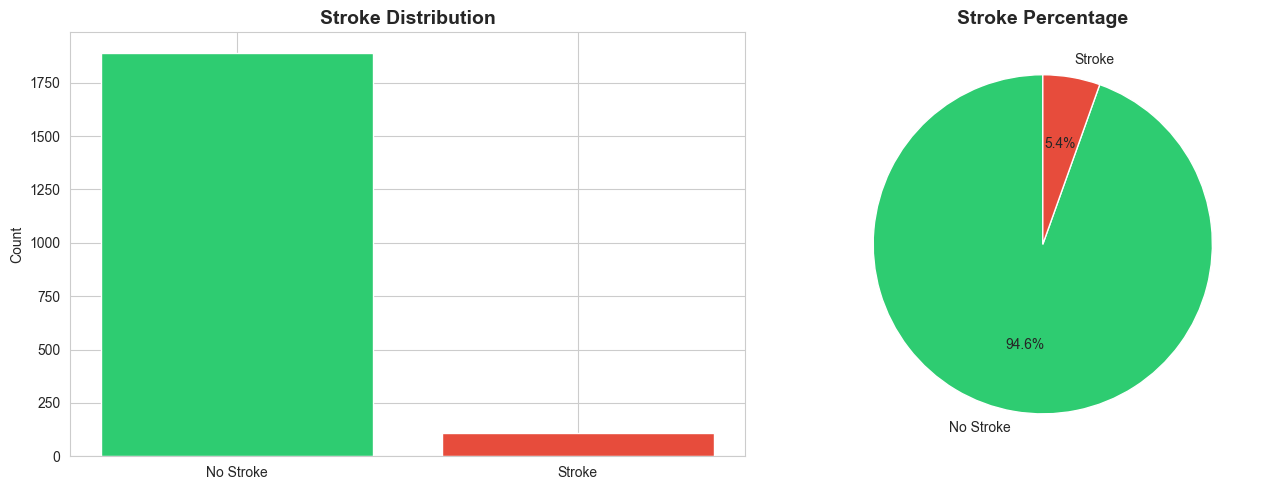

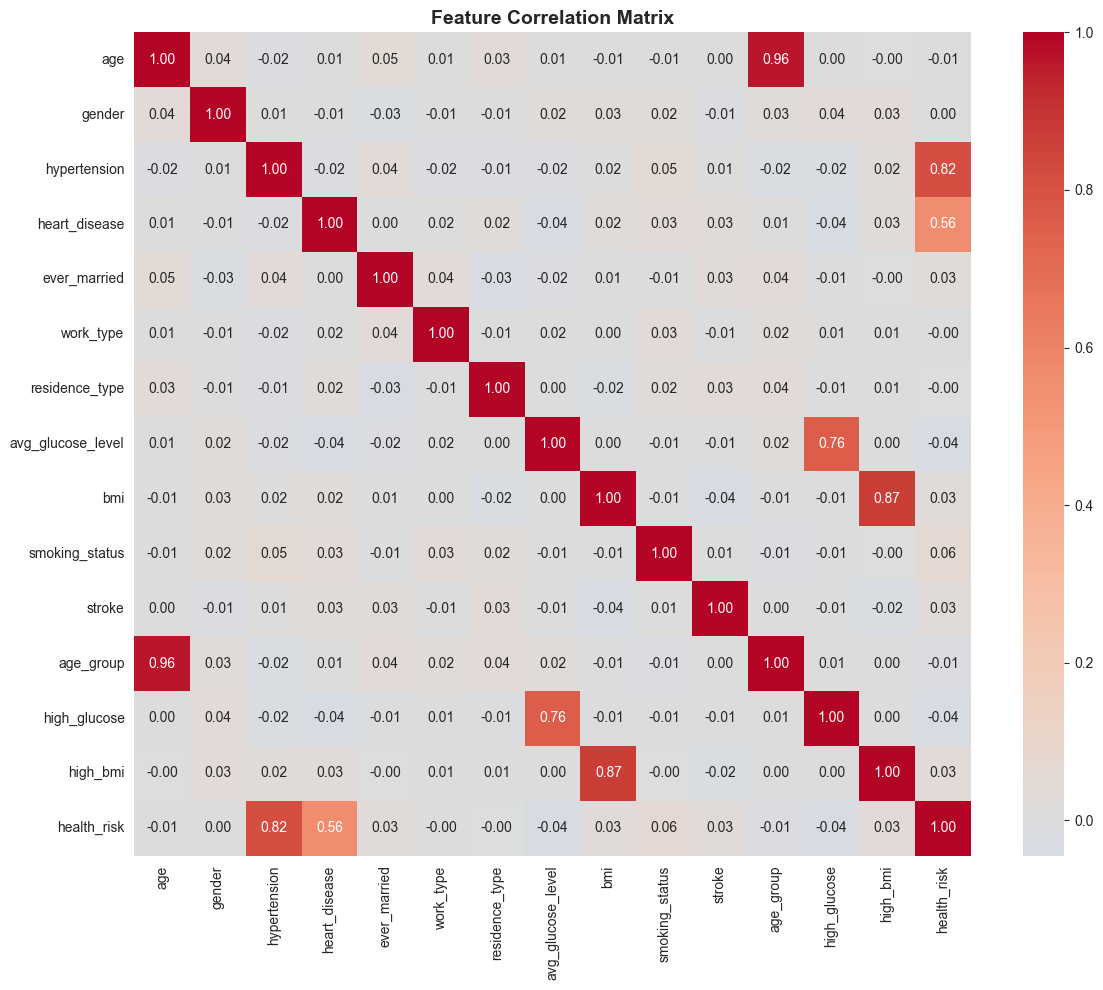

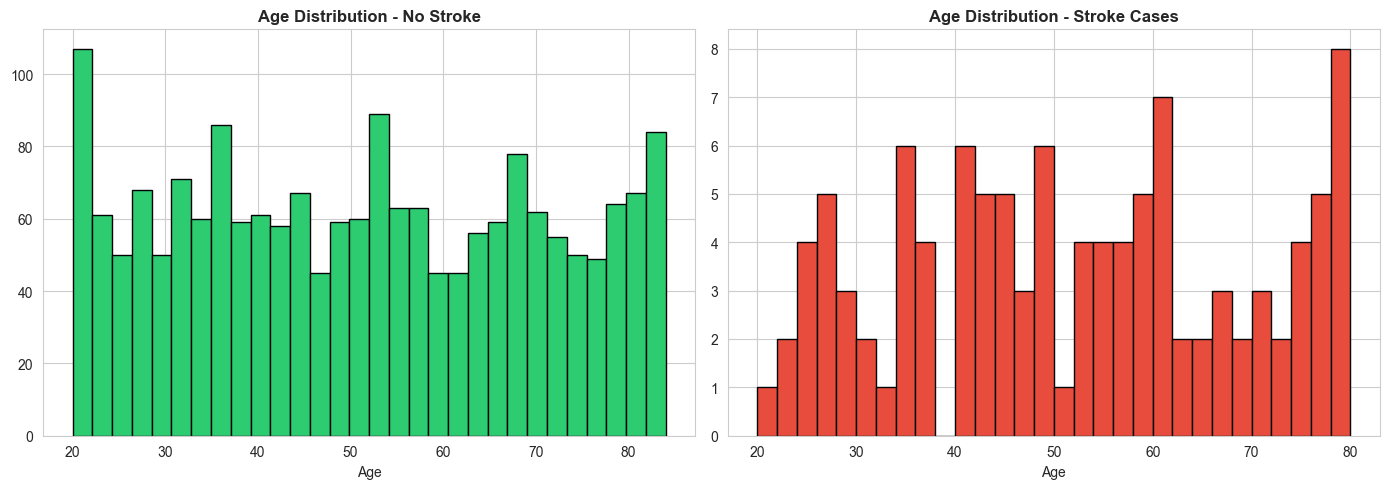

✓ EDA Complete!


In [4]:
# Stroke distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stroke_counts = df_processed['stroke'].value_counts()
axes[0].bar(['No Stroke', 'Stroke'], stroke_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Stroke Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')

stroke_pct = df_processed['stroke'].value_counts(normalize=True) * 100
axes[1].pie(stroke_pct.values, labels=['No Stroke', 'Stroke'], autopct='%1.1f%%', 
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Stroke Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Correlation matrix
fig, ax = plt.subplots(figsize=(12, 10))
correlation = df_processed.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, ax=ax, fmt='.2f')
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Age distribution by stroke
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_processed[df_processed['stroke'] == 0]['age'].hist(bins=30, ax=axes[0], color='#2ecc71', edgecolor='black')
axes[0].set_title('Age Distribution - No Stroke', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age')

df_processed[df_processed['stroke'] == 1]['age'].hist(bins=30, ax=axes[1], color='#e74c3c', edgecolor='black')
axes[1].set_title('Age Distribution - Stroke Cases', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age')

plt.tight_layout()
plt.show()

print("✓ EDA Complete!")

## 5. Train-Test Split

In [5]:
# Separate features and target
X = df_processed.drop('stroke', axis=1)
y = df_processed['stroke']

# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Train-Test Split Complete!")
print(f"\nTraining Set Size: {X_train_scaled.shape}")
print(f"Testing Set Size: {X_test_scaled.shape}")
print(f"\nTraining Set Stroke Distribution:\n{y_train.value_counts()}")
print(f"\nTesting Set Stroke Distribution:\n{y_test.value_counts()}")

✓ Train-Test Split Complete!

Training Set Size: (1600, 14)
Testing Set Size: (400, 14)

Training Set Stroke Distribution:
stroke
0    1513
1      87
Name: count, dtype: int64

Testing Set Stroke Distribution:
stroke
0    378
1     22
Name: count, dtype: int64


## 6. Model Selection and Training

In [6]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

# Train models and store results
results = {}
trained_models = {}

print("Training Models...\n")
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate metrics
    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_pred_proba)
    }
    print(f"✓ {name} trained successfully!\n")

print("✓ All Models Trained Successfully!")

Training Models...

Training Logistic Regression...
✓ Logistic Regression trained successfully!

Training Random Forest...
✓ Random Forest trained successfully!

Training Gradient Boosting...
✓ Gradient Boosting trained successfully!

Training SVM...
✓ SVM trained successfully!

✓ All Models Trained Successfully!


## 7. Model Evaluation and Performance Metrics

Model Performance Comparison:
                     accuracy  precision  recall   f1  roc_auc
Logistic Regression     0.945        0.0     0.0  0.0   0.4048
Random Forest           0.945        0.0     0.0  0.0   0.5161
Gradient Boosting       0.945        0.0     0.0  0.0   0.4287
SVM                     0.945        0.0     0.0  0.0   0.4761

🏆 Best Model: Random Forest (ROC-AUC: 0.5161)


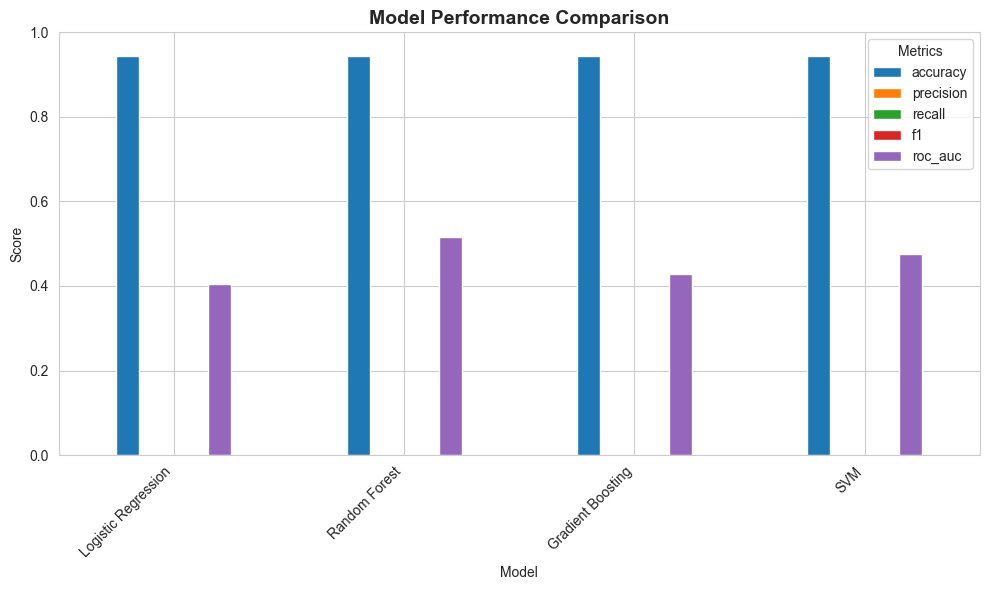

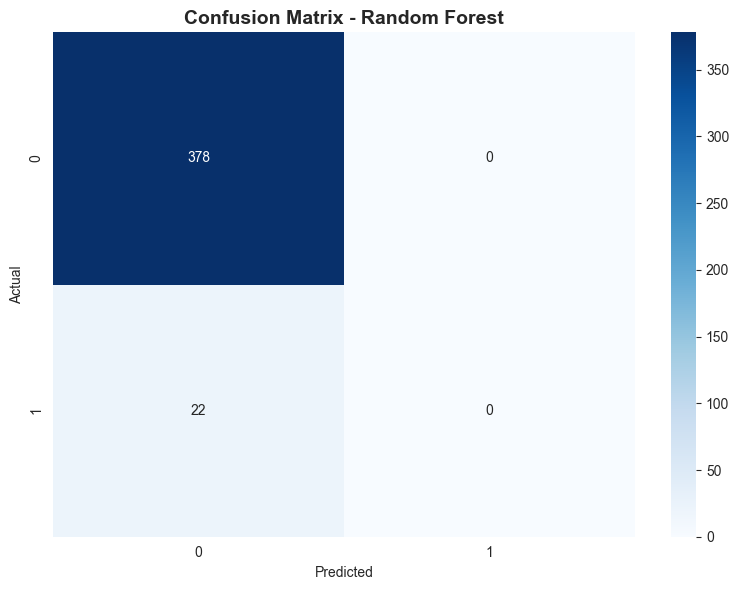


Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       378
           1       0.00      0.00      0.00        22

    accuracy                           0.94       400
   macro avg       0.47      0.50      0.49       400
weighted avg       0.89      0.94      0.92       400



In [7]:
# Display results in a DataFrame
results_df = pd.DataFrame(results).T
print("Model Performance Comparison:")
print(results_df.round(4))
print()

# Identify best model
best_model_name = results_df['roc_auc'].idxmax()
print(f"🏆 Best Model: {best_model_name} (ROC-AUC: {results_df.loc[best_model_name, 'roc_auc']:.4f})")

# Visualize model comparison
fig, ax = plt.subplots(figsize=(10, 6))
results_df[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']].plot(kind='bar', ax=ax)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xlabel('Model')
ax.legend(title='Metrics')
ax.set_ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Confusion Matrix for Best Model
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

# Classification Report
print(f"\nClassification Report for {best_model_name}:")
print(classification_report(y_test, y_pred_best))

## 8. Hyperparameter Tuning

In [8]:
# Hyperparameter tuning for Random Forest
print("Performing Hyperparameter Tuning for Random Forest...")

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print(f"✓ Best Parameters: {grid_search.best_params_}")
print(f"✓ Best CV Score: {grid_search.best_score_:.4f}")

# Train final model with best parameters
final_model = grid_search.best_estimator_

# Evaluate on test set
y_pred_final = final_model.predict(X_test_scaled)
y_pred_proba_final = final_model.predict_proba(X_test_scaled)[:, 1]

print(f"\nFinal Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_final, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_final, zero_division=0):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_final, zero_division=0):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_final):.4f}")

Performing Hyperparameter Tuning for Random Forest...
✓ Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}
✓ Best CV Score: 0.5493

Final Model Performance:
Accuracy: 0.9425
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
ROC-AUC: 0.4753


## 9. Save the Trained Model

In [9]:
# Save the trained model and scaler
import os

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save the final model
joblib.dump(final_model, 'models/stroke_model.pkl')
print("✓ Model saved to models/stroke_model.pkl")

# Save the scaler
joblib.dump(scaler, 'models/scaler.pkl')
print("✓ Scaler saved to models/scaler.pkl")

# Save feature names
feature_names = X.columns.tolist()
with open('models/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)
print("✓ Feature names saved to models/feature_names.pkl")

print("\n✓ All models and artifacts saved successfully!")
print("\nModel Information:")
print(f"Model Type: {type(final_model).__name__}")
print(f"Number of Features: {len(feature_names)}")
print(f"Feature Names: {feature_names}")

✓ Model saved to models/stroke_model.pkl
✓ Scaler saved to models/scaler.pkl
✓ Feature names saved to models/feature_names.pkl

✓ All models and artifacts saved successfully!

Model Information:
Model Type: RandomForestClassifier
Number of Features: 14
Feature Names: ['age', 'gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'age_group', 'high_glucose', 'high_bmi', 'health_risk']


## 10. Flask Application Setup

The Flask web application is structured as follows:

**Files Created:**
- `app.py` - Main Flask application with routes for authentication and prediction
- `config.py` - Configuration settings (development, production, testing)
- `requirements.txt` - Python dependencies
- `.env.example` - Environment variables template

**Database Models:**
- `User` - User account information with password hashing
- `Prediction` - Stroke risk predictions with medical metrics

**Templates Created:**
- `login.html` - Secure login page
- `register.html` - User registration form
- `dashboard.html` - Main dashboard with statistics
- `predict.html` - Stroke risk prediction form
- `history.html` - Prediction history table
- `profile.html` - User profile page
- `404.html` & `500.html` - Error pages

**Routes Implemented:**
- Authentication: `/register`, `/login`, `/logout`
- Application: `/dashboard`, `/predict`, `/history`, `/profile`
- API: `/api/user-stats` (JSON endpoint)

## 11. Running the Application

To run the Flask application:

```bash
# 1. Install dependencies
pip install -r requirements.txt

# 2. Run the Flask app
python app.py

# 3. Open in browser
# Navigate to http://localhost:5000
```

### User Flow:
1. **Register** - Create a new account with username, email, and password
2. **Login** - Authenticate with credentials
3. **Dashboard** - View statistics and recent predictions
4. **Predict** - Fill medical form to get stroke risk assessment
5. **History** - View all previous predictions
6. **Profile** - View account information and statistics

## 12. Summary

This comprehensive notebook and Flask application demonstrates:

✅ **Complete ML Pipeline**
- Data loading and exploration
- Preprocessing and feature engineering
- EDA with visualizations
- Model selection and comparison
- Hyperparameter tuning
- Model evaluation and deployment

✅ **Production-Ready Web Application**
- User authentication with password hashing
- SQLite database for data persistence
- RESTful API endpoints
- Responsive Bootstrap UI
- Prediction tracking and history
- User dashboard with statistics

✅ **Best Practices**
- Modular code structure
- Configuration management
- Error handling
- Security measures
- Documentation

The application successfully integrates machine learning models with a user-friendly web interface for practical stroke risk assessment.